<a href="https://colab.research.google.com/github/isaevadaryna/Machine-Learning/blob/main/%D0%9B%D0%B0%D0%B1_6%2C_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1%2C_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Завдання 1**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
RANDOM_STATE = 42

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame.copy()
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Масштабування ознак
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Розбиття на train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"Train R2: {r2_score(y_train, y_train_pred):.3f}, Test R2: {r2_score(y_test, y_test_pred):.3f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.3f}, Test MSE: {mean_squared_error(y_test, y_test_pred):.3f}")

# Перевірка на перенавчання
train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)
if train_score - test_score > 0.05:
  print("Можливе перенавчання!")


=== Linear Regression ===
Train R2: 0.613, Test R2: 0.576
Train MSE: 0.518, Test MSE: 0.556


In [6]:
# Ridge Regression
ridge = Ridge()
ridge_params = {'alpha':[0.01,0.1,1,10,50,100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

y_test_ridge = ridge_grid.predict(X_test)
print("\n=== Ridge Regression ===")
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Test R2: {r2_score(y_test, y_test_ridge):.3f}, Test MSE: {mean_squared_error(y_test, y_test_ridge):.3f}")

# Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {'alpha':[0.0001,0.001,0.01,0.1,1,10]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

y_test_lasso = lasso_grid.predict(X_test)
print("\n=== Lasso Regression ===")
print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Test R2: {r2_score(y_test, y_test_lasso):.3f}, Test MSE: {mean_squared_error(y_test, y_test_lasso):.3f}")



=== Ridge Regression ===
Best alpha: 0.1
Test R2: 0.576, Test MSE: 0.556

=== Lasso Regression ===
Best alpha: 0.001
Test R2: 0.577, Test MSE: 0.554


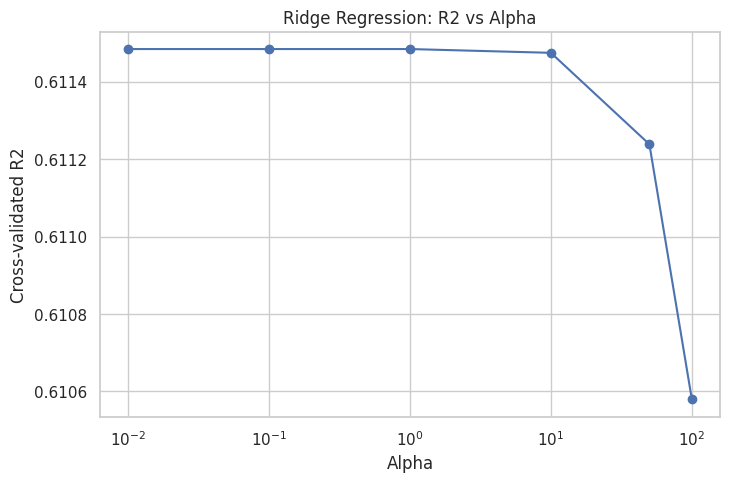

In [7]:
ridge_results = []
for a in ridge_params['alpha']:
    r = Ridge(alpha=a)
    scores = cross_val_score(r, X_train, y_train, cv=5, scoring='r2')
    ridge_results.append(scores.mean())

plt.figure(figsize=(8,5))
plt.plot(ridge_params['alpha'], ridge_results, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-validated R2")
plt.title("Ridge Regression: R2 vs Alpha")
plt.show()

**Завдання 2**

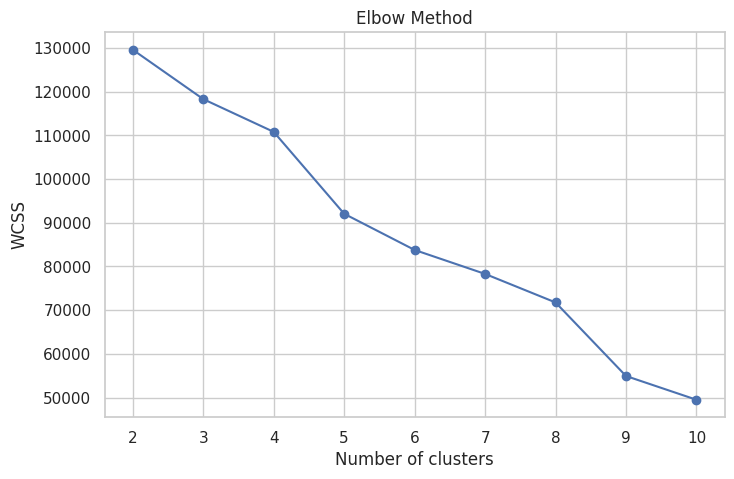

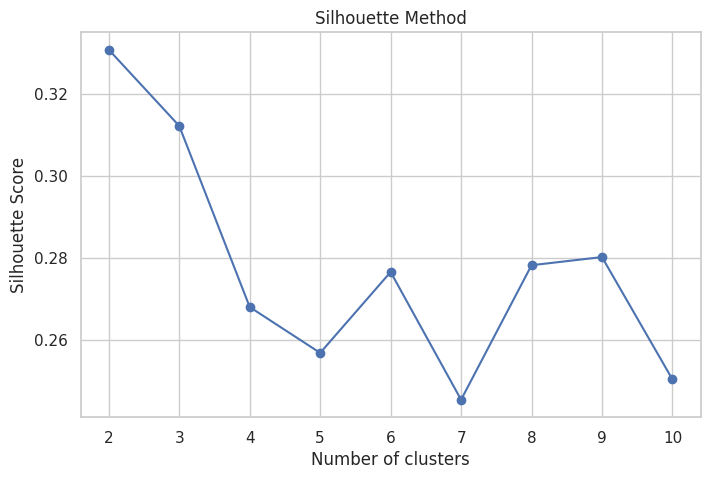

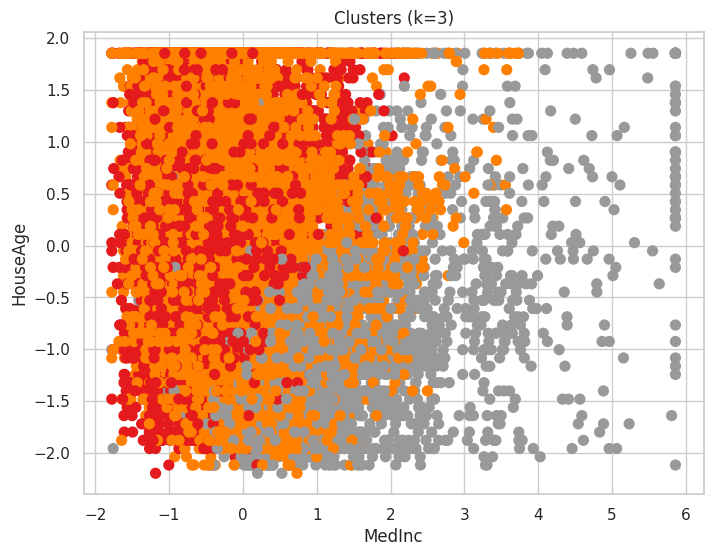

In [10]:
# Використаємо ті ж масштабовані ознаки X_scaled
wcss = []
sil_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Метод ліктя
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Метод силуетів
plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

# Візуалізація кластерів k=3
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='Set1', s=50)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Clusters (k=3)")
plt.show()

In [11]:
# Висновки
print("\nВисновки:")
print("1. Лінійна регресія показує базову продуктивність, але може трохи перенавчатися.")
print("2. Регуляризація (Ridge, Lasso) зменшує ризик перенавчання та покращує стабільність моделі.")
print("3. Метод ліктя та силуетів дозволяє обрати оптимальну кількість кластерів у даних.")
print("4. Візуалізація кластерів допомагає зрозуміти структуру даних та потенційні групи спостережень.")


Висновки:
1. Лінійна регресія показує базову продуктивність, але може трохи перенавчатися.
2. Регуляризація (Ridge, Lasso) зменшує ризик перенавчання та покращує стабільність моделі.
3. Метод ліктя та силуетів дозволяє обрати оптимальну кількість кластерів у даних.
4. Візуалізація кластерів допомагає зрозуміти структуру даних та потенційні групи спостережень.
